In [21]:
from pathlib import Path
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from skimage.draw import polygon


In [22]:
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"

random.seed(42)
np.random.seed(42)


In [23]:
NOTEBOOK_DIR = Path.cwd().resolve()
SEGMENTATION_ROOT = NOTEBOOK_DIR.parent
DATA_ROOT = SEGMENTATION_ROOT / "data"

dataset_root = DATA_ROOT / "EchoNet-Dynamic"
filelist_path = dataset_root / "FileList.csv"
tracings_path = dataset_root / "VolumeTracings.csv"
videos_dir = dataset_root / "Videos"

print("dataset_root:", dataset_root)
print("filelist_path exists:", filelist_path.exists())
print("tracings_path exists:", tracings_path.exists())
print("videos_dir exists:", videos_dir.exists())


dataset_root: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/data/EchoNet-Dynamic
filelist_path exists: True
tracings_path exists: True
videos_dir exists: True


In [24]:
file_df = pd.read_csv(filelist_path)
trace_df = pd.read_csv(tracings_path)

trace_df["FileStem"] = trace_df["FileName"].str.replace(".avi", "", regex=False)

print("file_df shape:", file_df.shape)
print("trace_df shape:", trace_df.shape)

display(file_df.head())
display(trace_df.head())


file_df shape: (10030, 9)
trace_df shape: (425010, 7)


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


,FileName,X1,Y1,X2,Y2,Frame,FileStem
0,0X100009310A3BD7FC.avi,51.260417,15.348958,64.932292,69.125000,46,0X100009310A3BD7FC
1,0X100009310A3BD7FC.avi,50.037611,17.167841,53.367222,16.321330,46,0X100009310A3BD7FC
2,0X100009310A3BD7FC.avi,49.157378,20.407629,57.090549,18.390722,46,0X100009310A3BD7FC
3,0X100009310A3BD7FC.avi,48.538173,23.581055,59.997339,20.667707,46,0X100009310A3BD7FC
4,0X100009310A3BD7FC.avi,47.918968,26.754480,62.904129,22.944693,46,0X100009310A3BD7FC


In [25]:
file_names = set(file_df["FileName"].astype(str))
trace_names = set(trace_df["FileStem"].astype(str))

traceable_video_names = sorted(file_names & trace_names)
missing_trace_video_names = sorted(file_names - trace_names)

print("Traceable videos:", len(traceable_video_names))
print("Missing trace videos:", len(missing_trace_video_names))
print("Missing trace sample:", missing_trace_video_names[:10])


Traceable videos: 10024
Missing trace videos: 6
Missing trace sample: ['0X234005774F4CB5CD', '0X2DC68261CBCC04AE', '0X35291BE9AB90FB89', '0X5515B0BD077BE68A', '0X5DD5283AC43CCDD1', '0X6C435C1B417FDE8A']


In [26]:
def resolve_video_path(file_name: str, videos_dir: Path) -> Path:
    candidate_1 = videos_dir / file_name
    candidate_2 = videos_dir / f"{file_name}.avi"

    if candidate_1.exists():
        return candidate_1
    if candidate_2.exists():
        return candidate_2

    raise FileNotFoundError(f"Could not resolve video path for: {file_name}")


In [27]:
def load_frame(video_path: Path, frame_index: int):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise ValueError(f"Could not read frame {frame_index} from {video_path}")

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame


In [28]:
def get_video_trace_rows(file_stem: str, trace_df: pd.DataFrame) -> pd.DataFrame:
    rows = trace_df[trace_df["FileStem"] == file_stem].copy()
    if rows.empty:
        raise ValueError(f"No tracing rows found for {file_stem}")
    return rows

def get_traced_frames_for_video(file_stem: str, trace_df: pd.DataFrame):
    rows = get_video_trace_rows(file_stem, trace_df)
    frames = sorted(rows["Frame"].unique().tolist())
    return frames


In [29]:
def get_frame_trace_points(file_stem: str, frame_index: int, trace_df: pd.DataFrame) -> np.ndarray:
    rows = trace_df[
        (trace_df["FileStem"] == file_stem) &
        (trace_df["Frame"] == frame_index)
    ].copy()

    if rows.empty:
        raise ValueError(f"No trace rows found for {file_stem} frame {frame_index}")

    points = rows[["X1", "Y1", "X2", "Y2"]].to_numpy(dtype=np.float32)
    return points


In [30]:
def tracing_points_to_polygon_vertices(points: np.ndarray):
    x1 = points[:, 0]
    y1 = points[:, 1]
    x2 = points[:, 2]
    y2 = points[:, 3]

    x = np.concatenate((x1[1:], np.flip(x2[1:])))
    y = np.concatenate((y1[1:], np.flip(y2[1:])))

    vertices = np.stack([x, y], axis=1)
    return vertices

In [31]:
def polygon_vertices_to_mask(vertices: np.ndarray, image_shape: tuple[int, int]) -> np.ndarray:
    height, width = image_shape
    
    rr, cc = polygon(
        np.rint(vertices[:, 1]).astype(np.int32),
        np.rint(vertices[:, 0]).astype(np.int32),
        shape=(height, width),
    )

    mask = np.zeros((height, width), dtype=np.uint8)
    mask[rr, cc] = 1
    return mask

In [32]:
def build_mask_for_video_frame(file_stem: str, frame_index: int, trace_df: pd.DataFrame, image_shape: tuple[int, int]):
    points = get_frame_trace_points(file_stem, frame_index, trace_df)
    vertices = tracing_points_to_polygon_vertices(points)
    mask = polygon_vertices_to_mask(vertices, image_shape=image_shape)
    return points, vertices, mask

In [33]:
sample_file_stem = random.choice(traceable_video_names)
sample_frames = get_traced_frames_for_video(sample_file_stem, trace_df)

print("Sample video:", sample_file_stem)
print("Traced frames:", sample_frames)

sample_video_path = resolve_video_path(sample_file_stem, videos_dir)
sample_frame = load_frame(sample_video_path, sample_frames[0])

print("Frame shape:", sample_frame.shape)


Sample video: 0X2694F675274D5ED6
Traced frames: [57, 75]
Frame shape: (112, 112, 3)


In [34]:
image_height, image_width = sample_frame.shape[:2]

sample_points, sample_vertices, sample_mask = build_mask_for_video_frame(
    file_stem=sample_file_stem,
    frame_index=sample_frames[0],
    trace_df=trace_df,
    image_shape=(image_height, image_width),
)

print("Points shape:", sample_points.shape)
print("Vertices shape:", sample_vertices.shape)
print("Mask shape:", sample_mask.shape)
print("Mask sum:", sample_mask.sum())


Points shape: (21, 4)
Vertices shape: (40, 2)
Mask shape: (112, 112)
Mask sum: 1146


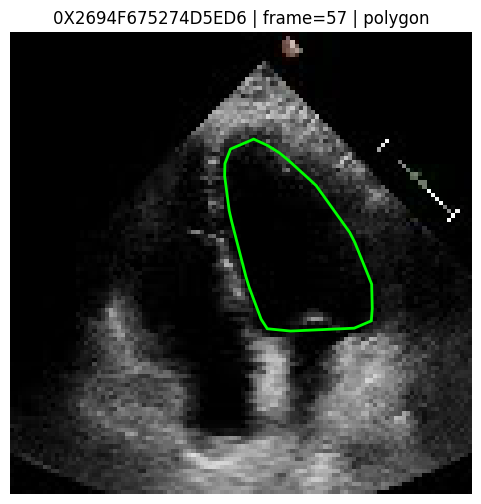

In [35]:
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(sample_frame)

poly = Polygon(sample_vertices, closed=True, fill=False, edgecolor="lime", linewidth=2)
ax.add_patch(poly)

ax.set_title(f"{sample_file_stem} | frame={sample_frames[0]} | polygon")
ax.axis("off")
plt.show()

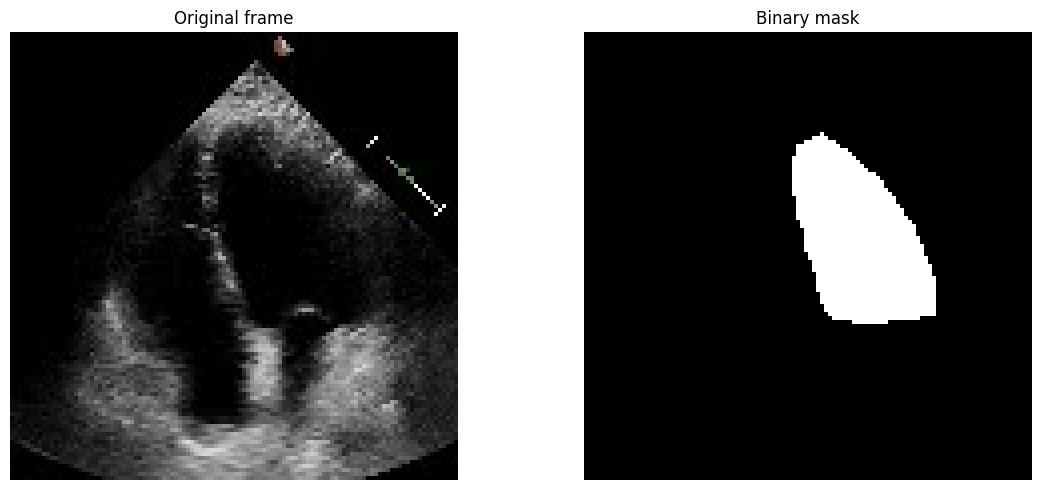

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(sample_frame)
axes[0].set_title("Original frame")
axes[0].axis("off")

axes[1].imshow(sample_mask, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()


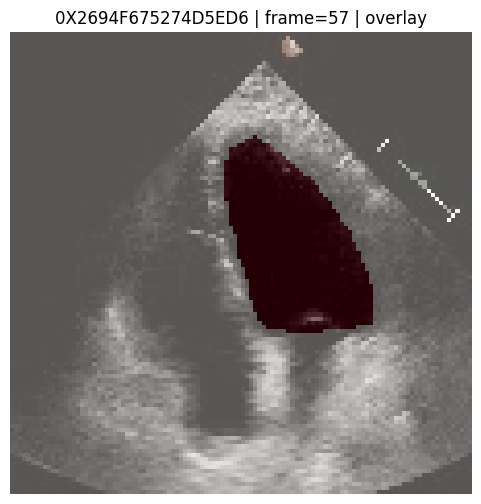

In [37]:
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(sample_frame)
ax.imshow(sample_mask, alpha=0.35, cmap="Reds")

ax.set_title(f"{sample_file_stem} | frame={sample_frames[0]} | overlay")
ax.axis("off")
plt.show()

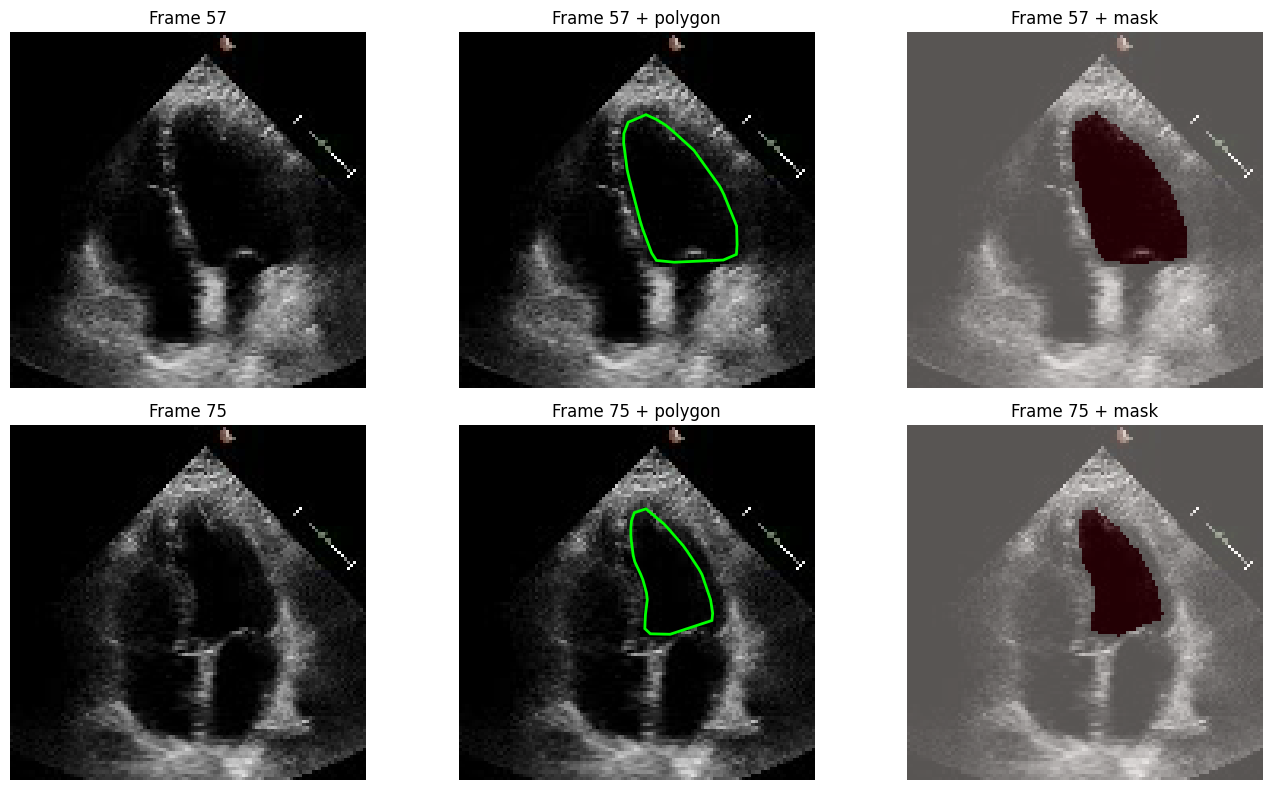

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row_idx, frame_idx in enumerate(sample_frames[:2]):
    frame = load_frame(sample_video_path, frame_idx)
    _, vertices, mask = build_mask_for_video_frame(
        file_stem=sample_file_stem,
        frame_index=frame_idx,
        trace_df=trace_df,
        image_shape=frame.shape[:2],
    )

    axes[row_idx, 0].imshow(frame)
    axes[row_idx, 0].set_title(f"Frame {frame_idx}")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(frame)
    poly = Polygon(vertices, closed=True, fill=False, edgecolor="lime", linewidth=2)
    axes[row_idx, 1].add_patch(poly)
    axes[row_idx, 1].set_title(f"Frame {frame_idx} + polygon")
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(frame)
    axes[row_idx, 2].imshow(mask, alpha=0.35, cmap="Reds")
    axes[row_idx, 2].set_title(f"Frame {frame_idx} + mask")
    axes[row_idx, 2].axis("off")

plt.tight_layout()
plt.show()


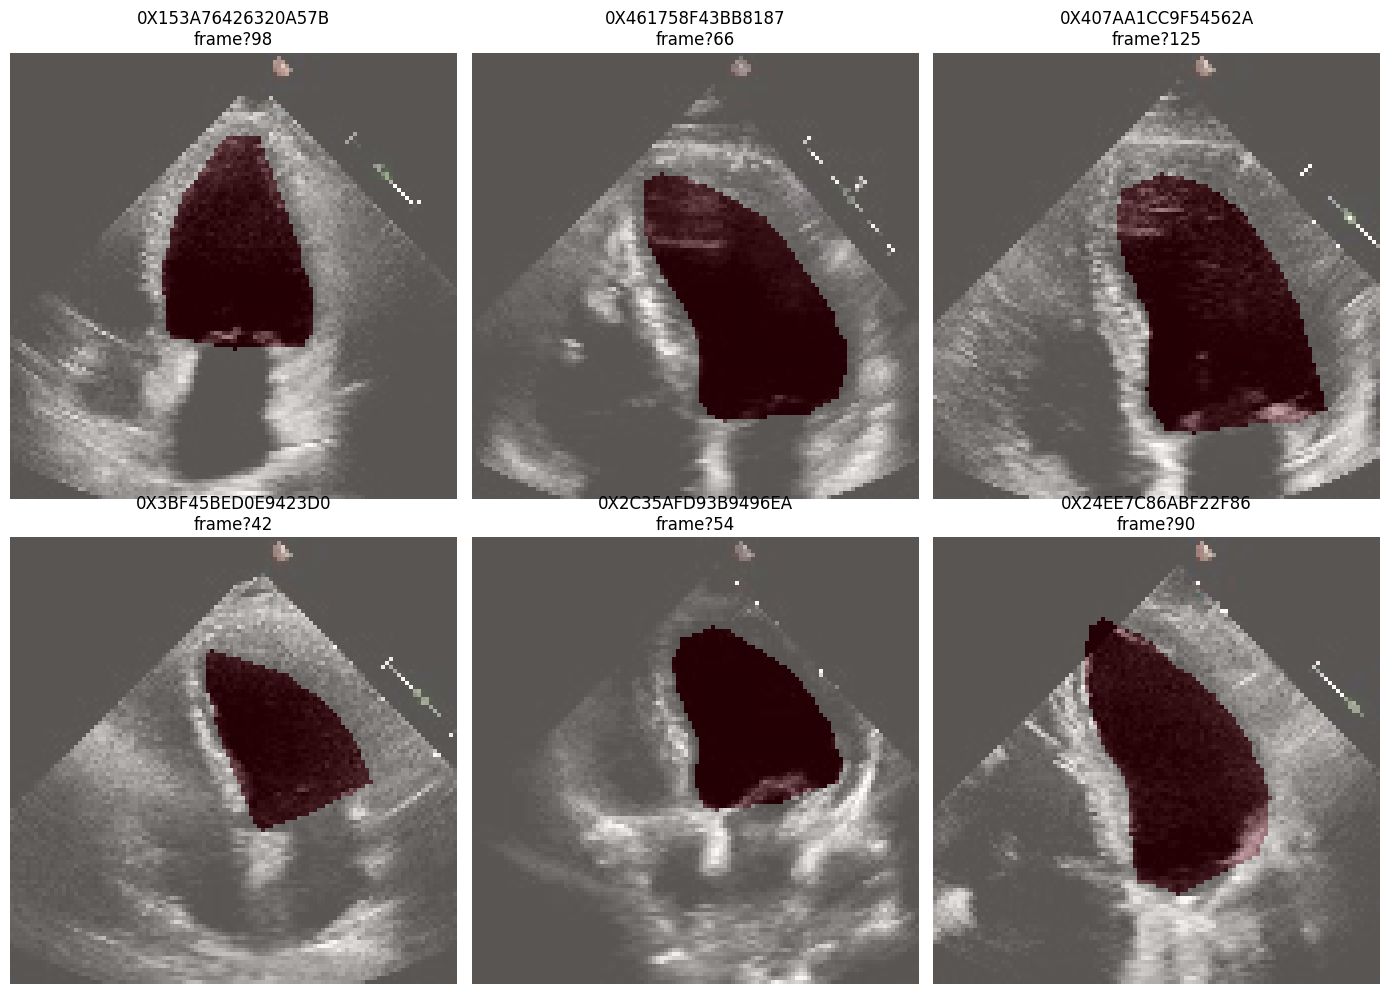

In [39]:
random_examples = random.sample(traceable_video_names, k=min(6, len(traceable_video_names)))

fig, axes = plt.subplots(2,3, figsize=(14,10))
axes = axes.flatten()

for ax, file_stem in zip(axes, random_examples):
    frames = get_traced_frames_for_video(file_stem, trace_df)
    frame_idx = frames[0]

    video_path = resolve_video_path(file_stem, videos_dir)
    frame = load_frame(video_path, frame_idx)
    _, vertices, mask = build_mask_for_video_frame(
        file_stem=file_stem,
        frame_index=frame_idx,
        trace_df=trace_df,
        image_shape=frame.shape[:2],
    )

    ax.imshow(frame)
    ax.imshow(mask, alpha=0.35, cmap="Reds")
    ax.set_title(f"{file_stem}\nframe?{frame_idx}")
    ax.axis("off")

for ax in axes[len(random_examples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [40]:
def mask_area(mask: np.ndarray) -> int:
    return int(mask.sum())

comparison_rows = []

sampled_for_area = random.sample(traceable_video_names, k=min(10, len(traceable_video_names)))

for file_stem in sampled_for_area:
    frames = get_traced_frames_for_video(file_stem, trace_df)
    video_path = resolve_video_path(file_stem, videos_dir)

    areas = []
    for frame_idx in frames:
        frame = load_frame(video_path, frame_idx)
        _, _, mask = build_mask_for_video_frame(
            file_stem=file_stem,
            frame_index=frame_idx,
            trace_df=trace_df,
            image_shape=frame.shape[:2],
        )
        areas.append((frame_idx, mask_area(mask)))

    areas = sorted(areas, key=lambda x: x[1])
    comparison_rows.append({
        "FileName": file_stem,
        "smaller_frame": areas[0][0],
        "smaller_area": areas[0][1],
        "larger_frame": areas[1][0],
        "larger_area": areas[1][1],
    })

area_compare_df = pd.DataFrame(comparison_rows)
display(area_compare_df.head(10))


,FileName,smaller_frame,smaller_area,larger_frame,larger_area
0,0X7AEB162B3A45EAA9,58,832,42,1357
1,0X21DB11780A6A35EE,53,1002,38,1802
2,0XB8A42CE677180DB,119,811,105,1123
3,0X62AADFDC4467B5EE,70,875,46,1636
4,0X16967BF5B2546925,145,969,127,1269
5,0X163A374094D066E8,112,1102,143,2081
6,0X2326F92D1F6B4980,55,528,39,867
7,0X3B296AB590431282,46,653,31,1298
8,0X3DF564B9BA59AC74,136,734,121,1200
9,0X7302BA5E11336B0D,69,785,52,1460


In [41]:
phase_rows = []

for file_stem in sampled_for_area:
    frames = get_traced_frames_for_video(file_stem, trace_df)
    video_path = resolve_video_path(file_stem, videos_dir)

    temp = []
    for frame_idx in frames:
        frame = load_frame(video_path, frame_idx)
        _, _, mask = build_mask_for_video_frame(
            file_stem=file_stem,
            frame_index=frame_idx,
            trace_df=trace_df,
            image_shape=frame.shape[:2],
        )
        temp.append((frame_idx, int(mask.sum())))

    temp = sorted(temp, key=lambda x: x[1])

    phase_rows.append({
        "FileName": file_stem,
        "Frame": temp[0][0],
        "Phase": "ES",
        "MaskArea": temp[0][1],
    })
    phase_rows.append({
        "FileName": file_stem,
        "Frame": temp[1][0],
        "Phase": "ED",
        "MaskArea": temp[1][1],
    })

phase_df = pd.DataFrame(phase_rows)
display(phase_df.head(20))


,FileName,Frame,Phase,MaskArea
0,0X7AEB162B3A45EAA9,58,ES,832
1,0X7AEB162B3A45EAA9,42,ED,1357
2,0X21DB11780A6A35EE,53,ES,1002
3,0X21DB11780A6A35EE,38,ED,1802
4,0XB8A42CE677180DB,119,ES,811
5,0XB8A42CE677180DB,105,ED,1123
6,0X62AADFDC4467B5EE,70,ES,875
7,0X62AADFDC4467B5EE,46,ED,1636
8,0X16967BF5B2546925,145,ES,969
9,0X16967BF5B2546925,127,ED,1269


In [42]:
frame_level_rows = []

for i, file_stem in enumerate(traceable_video_names, start=1):
    frames = get_traced_frames_for_video(file_stem, trace_df)

    frame_area_pairs = []
    video_path = resolve_video_path(file_stem, videos_dir)

    for frame_idx in frames:
        frame = load_frame(video_path, frame_idx)
        _, _, mask = build_mask_for_video_frame(
            file_stem=file_stem,
            frame_index=frame_idx,
            trace_df=trace_df,
            image_shape=frame.shape[:2],
        )
        frame_area_pairs.append((frame_idx, int(mask.sum())))

    frame_area_pairs = sorted(frame_area_pairs, key=lambda x: x[1])

    if len(frame_area_pairs) == 2:
        es_frame, es_area = frame_area_pairs[0]
        ed_frame, ed_area = frame_area_pairs[1]

        frame_level_rows.append({
            "FileName": file_stem,
            "Frame": es_frame,
            "Phase": "ES",
            "MaskArea": es_area,
        })
        frame_level_rows.append({
            "FileName": file_stem,
            "Frame": ed_frame,
            "Phase": "ED",
            "MaskArea": ed_area,
        })

    if i % 1000 == 0:
        print(f"Processed {i}/{len(traceable_video_names)} videos")

frame_level_df = pd.DataFrame(frame_level_rows)
print("frame_level_df shape:", frame_level_df.shape)
display(frame_level_df.head())


Processed 1000/10024 videos
Processed 2000/10024 videos
Processed 3000/10024 videos
Processed 4000/10024 videos
Processed 5000/10024 videos
Processed 6000/10024 videos
Processed 7000/10024 videos
Processed 8000/10024 videos
Processed 9000/10024 videos
Processed 10000/10024 videos
frame_level_df shape: (20048, 4)


,FileName,Frame,Phase,MaskArea
0,0X100009310A3BD7FC,61,ES,540
1,0X100009310A3BD7FC,46,ED,1311
2,0X1002E8FBACD08477,18,ES,663
3,0X1002E8FBACD08477,3,ED,1193
4,0X1005D03EED19C65B,35,ES,454


In [43]:
frame_level_df = frame_level_df.merge(
    file_df,
    on="FileName",
    how="left"
)

print("Merged frame-level shape:", frame_level_df.shape)
display(frame_level_df.head())


Merged frame-level shape: (20048, 12)


,FileName,Frame,Phase,MaskArea,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,61,ES,540,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X100009310A3BD7FC,46,ED,1311,78.498406,14.881368,69.210534,112,112,50,174,VAL
2,0X1002E8FBACD08477,18,ES,663,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
3,0X1002E8FBACD08477,3,ED,1193,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
4,0X1005D03EED19C65B,35,ES,454,62.363798,14.267784,37.909734,112,112,50,104,TRAIN


In [44]:
print("Phase counts:")
display(frame_level_df["Phase"].value_counts())

print("\nSplit counts:")
display(frame_level_df["Split"].value_counts())

print("\nPhase x Split:")
display(pd.crosstab(frame_level_df["Split"], frame_level_df["Phase"]))


Phase counts:


Phase
ES    10024
ED    10024
Name: count, dtype: int64


Split counts:


Split
TRAIN    14920
VAL       2576
TEST      2552
Name: count, dtype: int64


Phase x Split:


Phase,ED,ES
Split,,
TEST,1276,1276
TRAIN,7460,7460
VAL,1288,1288


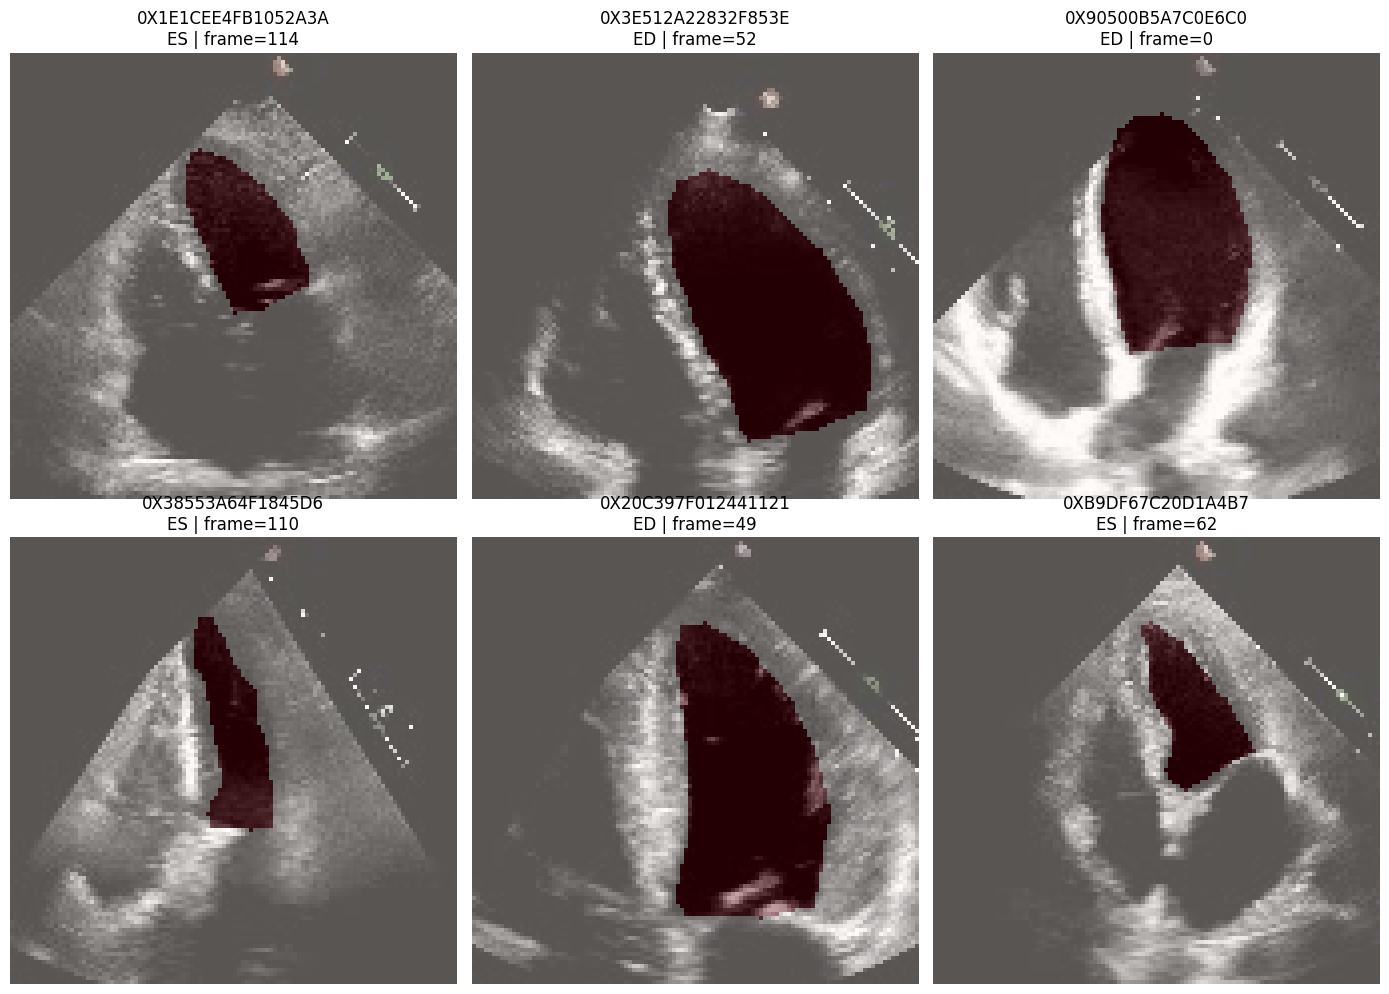

In [45]:
sample_rows = frame_level_df.sample(n=min(6, len(frame_level_df)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    file_stem = row["FileName"]
    frame_idx = int(row["Frame"])
    phase = row["Phase"]

    video_path = resolve_video_path(file_stem, videos_dir)
    frame = load_frame(video_path, frame_idx)
    _, _, mask = build_mask_for_video_frame(
        file_stem=file_stem,
        frame_index=frame_idx,
        trace_df=trace_df,
        image_shape=frame.shape[:2],
    )

    ax.imshow(frame)
    ax.imshow(mask, alpha=0.35, cmap="Reds")
    ax.set_title(f"{file_stem}\n{phase} | frame={frame_idx}")
    ax.axis("off")

for ax in axes[len(sample_rows):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [46]:
summary = {
    "n_traceable_videos": len(traceable_video_names),
    "n_missing_trace_videos": len(missing_trace_video_names),
    "n_frame_level_examples": len(frame_level_df),
    "phase_counts": frame_level_df["Phase"].value_counts().to_dict(),
    "split_counts": frame_level_df["Split"].value_counts().to_dict(),
}

summary


{'n_traceable_videos': 10024,
 'n_missing_trace_videos': 6,
 'n_frame_level_examples': 20048,
 'phase_counts': {'ES': 10024, 'ED': 10024},
 'split_counts': {'TRAIN': 14920, 'VAL': 2576, 'TEST': 2552}}